[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/axr/blob/master/axr/00_intro.ipynb)

# Introducción

El aprendizaje por refuerzo explora una aproximación computacional al aprendizaje por interacción. De la misma manera que cuando aprendemos a conducir estamos atentos a cómo reacciona nuestro entorno a nuestras acciones y buscamos maneras de influenciarlo a través de nuestro comportamiento, el aprendizaje por refuerzo estudia cómo agentes computacionales pueden desarrollar comportamientos inteligentes a través de este tipo de interacción.

## Aprendizaje por refuerzo


El aprendizaje por refuerzo, de ahora en adelante **axr**, consiste en aprender qué hacer (cómo relacionar situaciones y acciones) con el objetivo de maximizar una recompensa numérica. En ningún momento especificamos qué acciones debe tomar un agente, sino que le dejamos descubrir cuales son las que le darán una mayor recompensa. En la mayoría de situaciones, una acción no solo afectará a la recompensa inmediata, si no que tendrá un efecto en todas las situaciones futuras. Estas dos propiedades, búsqueda por prueba y error y futuras recompensas, son las más importantes del axr.

Para formalizar el problema del axr utilizamos ideas del campo de la teoría de sistemas dinámicos, en concreto el control óptimo de procesos de Markov incompletos. La idea básica consiste en aprender los aspectos más importantes sobre el problema real al que nuestro agente se enfrenta a través de la interacción con el entrono para conseguir su objetivo. El agente tiene que ser capaz de precibir su entorno y de llevar a cabo acciones que afecten a su estado. También necesita uno o varios objetivos relacionados con el estado del entorno. Un proceso de decisión de Markov incluye estos tres aspectos: percepción, acción y objetivo. Cualquier método que sea capaz de resolver este tipo de problemas se considera como un método de axr.

El axr está considerado como un paradigma del *machine learning* diferente al aprendizaje supervisado y no supervisado. Se diferencia del aprendizaje supervisado en que no siempre será posible obtener ejemplos del comportamiento deseado para nuestro agente en cualquier tipo de situación en la que se pueda encontrar, por lo que deberá ser capaz de aprender de su propia experiencia. Por otro lado, se diferencia del aprendizaje no supervisado ya que éste no es capaz por si mismo de resolver el problema de maximización de la recompensa.

El principal problema al que nos enfrentamos en el axr es el balance entre **exploración** y **explotación**. Para obtener la máxima recompensa, un agente podría escoger aquellas acciones que ya conoce que y que le direon buenos resultados. Sin embargo, el hecho de explorar nuevas acciones podría, eventualmente, dar mucho mejor resultado. Así pues, nuestro agente tiene que ser capaz de explotar su conocimiento para obtener recompensa pero también de explorar para descubrir mejores acciones. El problema es que ninguna de las dos aproximaciones puede llevarse a cabo de manera independiente para resolver un problema. Un agente debe probar muchas acciones y, poco a poco, favorecer aquellas que parezcan ser mejores. Este problema sigue sin estar resuelto.

Otra propiedad importante que diferencia al axr de otro métodos es su capacidad de considerar todo el dominio del problema de un agente interactuando con su entrono, y no pequeñas partes o sub-tareas que puedan resolverse de manera independiente para llevar al objetivo final.

## Ejemplos

Algunos ejemplos interesantes de aplicaciones del axr son:

- Agentes que son capaces de jugar a juegos: ajedrez, go, atari, starcraft ...
- Sistemas de control adaptativo en entornos industriales: refinerías, fábricas, cadenas de montaje, ...
- Robótica
- Conducción autónoma: el coche recibe información de su entorno a través de sus cámaras y sensores y ejecuta comandos para acelerar, frenar, girar el volante, ...

Como vemos, todos los ejemplos comparten la existencia de un agente en constante interacción con su entorno para lograr un objetivo (a pesar de la posible incertidumbre). Tomar una decisión puede afectar a las acciones y oportunidades futuras, por lo que la elección de una accion requiere capacidad de planificación y predicción. Además, gracias a su interacción con el entorno, un agente puede adaptarse y aprender constantemente, ajustándose si es necesario para mejorar. De todas las formas de inteligencia computacional, el axr es el que más se asemeja a la forma en la que personas y animales actuamos.


## Elementos del axr


Además del agente y del entorno, existen cuatro subelementos esenciales en un sistema de axr:

- **Política**: define el comportamiento de el agente en cada momento. Relaciona el estado que el agente percibe de su entorno con todas las posibles acciones que puede tomar. Puede ser tan simple como una función o una tabla, o tan complicada como un proceso de búsqueda. La política define completamente el comportamiento de un agente.
- **Recompensa**: define el objetivo del problema, y es un un valor numérico que en cada momento el entorno envía al agente, el cual tiene el único objetivo de maximizarlo. Es el valor principal a tener en cuenta a la hora de alterar la política de un agente.
- **Función de valor**: mientras que la recompensa indica la calidad de un estado de manera inmediata, la función de valor indica la calidad a largo plazo. El valor de un estado es la cantidad total de recompensa que un agente espera acumular en el futuro empezando en ese mismo estado. De esta manera, estados con una baja recompensa en relación a otros puede ser preferible si su valor es mayor (los estados futuros a los que nos permite llegar proporcionarán mayor recompensa). Así pues, favoreceremos acciones que impliquen mayor valor sobre recompensas inmediatas. El pricipal problema será estimar estos valores, ya que para ellos nuestro agente deberá explorar de manera repetida el entorno actualizando su información para poder llegar a ser capaz de tomar decisiones con fundamento.
- **Modelo** del entorno: imita el comportamiento del entorno y sirve para planificar acciones considerando estados futuros que todavía no se han experimentado. El uso de un modelo del entorno nos permite dividir los métodos de axr en métodos sin modelos, en el que un agente aprende por prueba y error (lo opuesto a la planificación) y métodos con modelo, aunque en varias aplicaciones esta línea es un poco difusa ya que se combinan ambas opciones.

## Ejemplo de aplicación: tres en raya



Con el objetivo de ilustrar la idea general del axr vamos a considerar un ejemplo en detalle: el juego del tres en raya. En este juego, dos jugadores se turnan para dibujar una X o una O en un tablero con 3x3 posiciones. El primer jugador en conseguir dibujar tres figuras en una línea horizontal, vertical o diagonal, gana. Nuestro objetivo es conseguir un agente que sea capaz de ganar siempre a este juego.

![](https://camo.githubusercontent.com/9b5f16d0451a8b6faf1ec45a6afbe22f55bbe1f9/68747470733a2f2f7468756d62732e6766796361742e636f6d2f506f697365644772697070696e67466f782d736d616c6c2e676966)

Para resolver este juego con axr, en primer lugar definimos una tabla de números, uno por cada posible estado del juego. Cada numero respresentará la probabilidad de ganar el juego desde ese estado, el *valor* del estado. Así pues, la tabla sería la *función de valor*. Un estado $A$ es considerado mejor que un estado $B$ si el valor estimado de la probabilidad de ganar el juego desde $A$ es mayor que desde $B$. Si jugásemos con las Xs, todos los estados con tres X en raya tenría un valor de 1, ya que hemos ganado el juego. De la misma manera, cualquier estado con tres Os en raya tendría un valor de 0, hemos perdido. Para la inicialización de la tabla, podemos establecer el resto de valores en 0.5 (50% de posibilidades de ganar).

Nuestro agente jugará muchas partidas contra un oponente (que puede ser otro agente). En cada turno evaluamos los estados que resultarían de cada posible movimiento (posiciones no ocupadas) y elegimos aquella con un mayor *valor*. Ocasionalmente, elegiremos una acción aleatoria con el objetivo de explorar nuevos movimientos.
        
Mientras el agente va jugando, tendremos que actualizar la función de valor. Para ello, después de cada movimiento, cambiaremos el valor del estado del que venimos para que se acerque al valor del estado actual.

$$
V(S_t) \leftarrow V(S_t) + \alpha [V(S_{t+1}) - V(S_t)]
$$
      
donde $S_t$ denote el estado del que venimos, $S_{t+1}$ es el nuevo estado después del movimiento, $V(S_t)$ es el valor del estado $S_t$ y $\alpha$ es el ratio de aprendizaje.

In [16]:
import numpy as np


class Board():
    def __init__(self):
        self.state = np.zeros((3,3))

    def valid_moves(self):
        return [(i, j) for j in range(3) for i in range(3) if self.state[i, j] == 0]

    def update(self, symbol, row, col):
        if self.state[row, col] == 0:
            self.state[row, col] = symbol
        else:
            raise ValueError ("movimiento ilegal, posicion ya marcada !")

    def is_game_over(self):
        # comprobar filas y columnas
        if (self.state.sum(axis=0) == 3).sum() >= 1 or (self.state.sum(axis=1) == 3).sum() >= 1:
            return 1
        if (self.state.sum(axis=0) == -3).sum() >= 1 or (self.state.sum(axis=1) == -3).sum() >= 1:
            return -1
        # comprobar diagonales
        diag_sums = [
            sum([self.state[i, i] for i in range(3)]),
            sum([self.state[i, 3 - i - 1] for i in range(3)]),
        ]
        if diag_sums[0] == 3 or diag_sums[1] == 3:
            return 1
        if diag_sums[0] == -3 or diag_sums[1] == -3:
            return -1
        # empate
        if len(self.valid_moves()) == 0:
            return 0
        # seguir jugando
        return None

    def reset(self):
        self.state = np.zeros((3,3))


In [17]:
from tqdm import tqdm

class Game():
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board()

    def selfplay(self, rounds=100):
        wins = [0, 0]
        for i in tqdm(range(1, rounds + 1)):
            self.board.reset()
            for player in self.players:
                player.reset()
            game_over = False
            while not game_over:
                for player in self.players:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for player in self.players:
                        player.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break
            self.reward()
            for ix, player in enumerate(self.players):
                if self.board.is_game_over() == player.symbol:
                    wins[ix] += 1
        return wins


    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0: # empate
            for player in self.players:
                player.reward(0.5)
        else: # le damos 1 recompensa al jugador que gana
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)

In [18]:
class Agent():
    def __init__(self, alpha=0.5, prob_exp=0.5):
        self.value_function = {} # tabla con pares estado -> valor
        self.alpha = alpha         # learning rate
        self.positions = []       # guardamos todas las posiciones de la partida
        self.prob_exp = prob_exp   # probabilidad de explorar

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        # exploracion
        if explore and np.random.uniform(0, 1) < self.prob_exp:
            # vamos a una posición aleatoria
            ix = np.random.choice(len(valid_moves))
            return valid_moves[ix]
        # explotacion
        # vamos a la posición con más valor
        max_value = -1000
        for row, col in valid_moves:
            next_board = board.state.copy()
            next_board[row, col] = self.symbol
            next_state = str(next_board.reshape(3*3))
            value = 0 if self.value_function.get(next_state) is None else self.value_function.get(next_state)
            if value >= max_value:
                max_value = value
                best_row, best_col = row, col
        return best_row, best_col

    def update(self, board):
        self.positions.append(str(board.state.reshape(3*3)))


    def reward(self, reward):
        # al final de la partida (cuando recibimos la recompensa)
        # iteramos por tods los estados actualizando su valor en la tabla
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

In [19]:
def isGameOver(estado):
    # comprobar filas y columnas
    if (estado.sum(axis=0) == 3).sum() >= 1 or (estado.sum(axis=1) == 3).sum() >= 1:
        return 1
    if (estado.sum(axis=0) == -3).sum() >= 1 or (estado.sum(axis=1) == -3).sum() >= 1:
        return -1
    # comprobar diagonales
    diag_sums = [
        sum([estado[i, i] for i in range(3)]),
        sum([estado[i, 3 - i - 1] for i in range(3)]),
    ]
    if diag_sums[0] == 3 or diag_sums[1] == 3:
        return 1
    if diag_sums[0] == -3 or diag_sums[1] == -3:
        return -1
    if len(movimientosValidos(estado)) == 0:
        return 0

def movimientosValidos(estado):
    return [(i, j) for j in range(3) for i in range(3) if estado[i, j] == 0]


In [20]:
partidas = 100
turnos = 10
epsilons = [0, 0.04, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
for ej in range(partidas):
     for i,e in enumerate(epsilons):
        ac = {}
        for exp in range(turnos):
            estado = np.zeros((3,3))
            posicion = {}
            turno = 1
            while True:
                validos = movimientosValidos(estado)
                if not validos:
                    break
                if turno == 1:
                    if np.random.uniform(0, 1) < e:
                        indice = np.random.choice(len(validos))
                        row,col = validos[indice]
                    else:
                        max_value = -1000
                        best_move = validos[0]
                        for r,c in validos:
                            es = estado.copy()
                            es[r,c] = 1
                            k = str(es.reshape(3*3))
                            val = ac.get(k, 0)
                            if val > max_value:
                                max_value = val
                                best_move = (r,c)
                        row, col = best_move
                    estado[row, col] = 1
                    posicion[str(estado.reshape(3*3))] = (row, col)
                else:
                    indice = np.random.choice(len(validos))
                    row, col = validos[indice]
                    estado[row, col] = -1
                resultado = isGameOver(estado)
                if resultado is not None:
                    if resultado == 1:
                        recompensa = 1
                    elif resultado == -1:
                        recompensa = 0
                    else:
                        recompensa = 0
                    for pos in reversed(posicion.keys()):
                        if ac.get(pos) is None:
                            ac[pos] = 0
                        ac[pos] += 0.5 * (recompensa - ac[pos])
                        recompensa = ac[pos]
                    recompensas_medias[i, exp] += resultado
recompensas_medias /= partidas


incrementacion exp

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\jorge\AppData\Local\Temp\ipykernel_32720\42366568.py:4: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}')


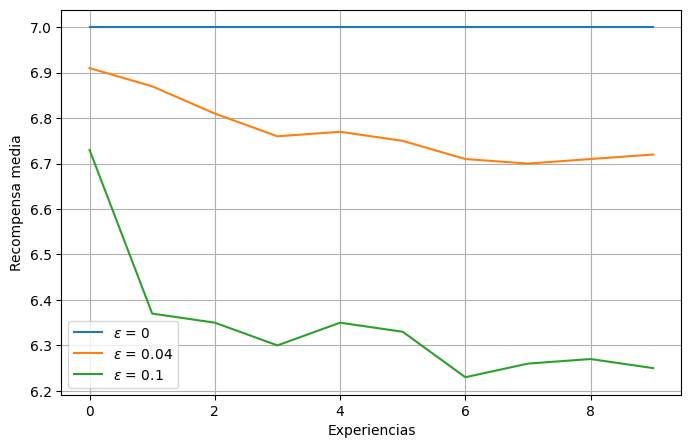

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.show()

In [5]:
partidas = 1000
turnos = 100
epsilons = [0, 0.04, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))
for ej in range(partidas):
     for i,e in enumerate(epsilons):
        agent1 = Agent(prob_exp=e)
        agent2 = Agent()
        game = Game(agent1, agent2)
        wins = game.selfplay(rounds=turnos)
        recompensas_medias[i] += wins[0] / turnos
        acciones_optimas[i] += wins[0] / turnos

100%|██████████| 100/100 [00:00<00:00, 283.25it/s]


In [ ]:
partidas = 1000
turnos = 100
alpha = 0.5
epsilons = [0, 0.04, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
for ej in range(partidas):
     for i,e in enumerate(epsilons):
        ac = {}
        for exp in range(turnos):
            estado = np.zeros((3,3))
            posicion = {}
            turno = 1
            while True:
                validos = movimientosValidos(estado)
                if not validos:
                    break
                if turno == 1:
                    if np.random.uniform(0, 1) < e:
                        indice = np.random.choice(len(validos))
                        row,col = validos[indice]
                    else:
                        max_value = -1000
                        best_move = validos[0]
                        for r,c in validos:
                            es = estado.copy()
                            es[r,c] = 1
                            k = str(es.reshape(3*3))
                            val = ac.get(k, 0)
                            if val > max_value:
                                max_value = val
                                best_move = (r,c)
                        row, col = best_move
                    estado[row, col] = 1
                    posicion[str(estado.reshape(3*3))] = (row, col)
                else:
                    indice = np.random.choice(len(validos))
                    row, col = validos[indice]
                    estado[row, col] = -1
                resultado = isGameOver(estado)
                if resultado is not None:
                    if resultado == 1:
                        recompensa = 1
                    elif resultado == -1:
                        recompensa = 0
                    else:
                        recompensa = 0
                    for pos in reversed(posicion.keys()):
                        if ac.get(pos) is None:
                            ac[pos] = 0
                        ac[pos] += alpha * (recompensa - ac[pos])
                        recompensa = ac[pos]
                    recompensas_medias[i, exp] += resultado
recompensas_medias /= partidas


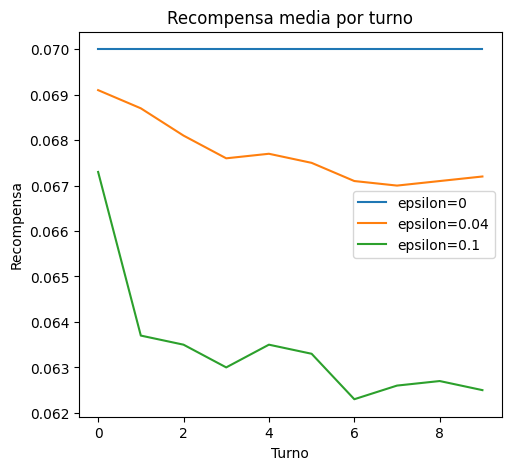

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(recompensas_medias[i] / partidas, label=f'epsilon={epsilon}')
plt.title('Recompensa media por turno') 
plt.xlabel('Turno')
plt.ylabel('Recompensa')
plt.legend()
plt.show()

In [ ]:
epsilons = [0, 0.04, 0.1]
for i, epsilon in enumerate(epsilons):
    agent1 = Agent(prob_exp=epsilon)
agent2 = Agent()

game = Game(agent1, agent2)

game.selfplay(300000)

100%|██████████| 300000/300000 [17:47<00:00, 280.96it/s]


[156244, 95577]

In [ ]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 1. 1. -1. 0. 1. -1. 0. -1. 1.],1.0
1,[ 0. -1. -1. 1. 0. -1. 1. 1. 1.],1.0
2,[ 1. 1. 1. 0. 0. -1. 0. 0. -1.],1.0
3,[ 1. 1. -1. -1. 1. 1. -1. 1. -1.],1.0
4,[ 1. 1. -1. -1. 0. 1. -1. 1. -1.],1.0
...,...,...
5472,[ 0. 1. 0. -1. -1. -1. 1. 1. 0.],0.0
5473,[-1. 1. 0. -1. 0. 1. -1. 1. 0.],0.0
5474,[-1. 1. 1. -1. -1. -1. 1. 1. 0.],0.0
5475,[-1. -1. 0. 1. 0. 1. 1. 1. -1.],0.0


In [ ]:
import pickle

with open('agente.pickle', 'wb') as handle:
    pickle.dump(agent1.value_function, handle, protocol=pickle.HIGHEST_PROTOCOL)

Este ejemplo sirve para ilustrar algunas de las propiedades clave del axr. En primer lugar, aprender a través de la interacción con el entorno (en este caso el otro agente). En segundo lugar, tenemos un objetivo claro y el comportamiento correcto del agente requiere de planificación y predicción que tenga en cuenta los efectos futuros de sus acciones.

##  Resumen

El aprendizaje por refuerzo es una aproximación computacional a la comprensión y automatización del aprendizaje por objetivos y toma de decisiones. En esta aproximación, una agente aprende a través de la interacción directa con su entorno sin necesidad de supervisión explícita. Utiliza procesos de decisión de Markov para definir la interacción entre el agente y su entorno en términos de estados, acciones y recompensas. Los conceptos de valor y función de valor son la clave de muchos métodos de axr ya que representan una manera eficiente de búsqueda en el espacio de políticas.